In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

### Задание 1

In [3]:
def f(x):
    """Функция f(x) = 3*sin(8x) - 0.7x + 0.9"""
    return 3 * math.sin(8 * x) - 0.7 * x + 0.9

--- Отделение корней на отрезке [-1, 1] ---


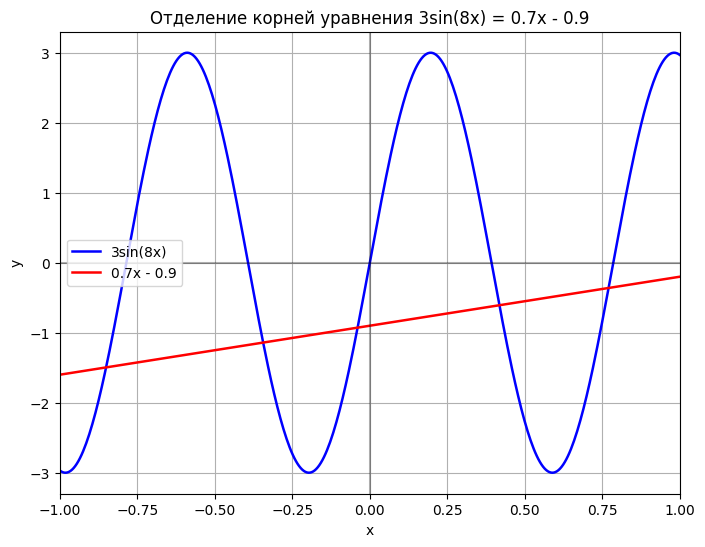

Корень на отрезке [-0.85; -0.85]
Корень на отрезке [-0.35; -0.34]
Корень на отрезке [-0.04; -0.04]
Корень на отрезке [0.41; 0.42]
Корень на отрезке [0.77; 0.77]


In [4]:
print("--- Отделение корней на отрезке [-1, 1] ---")

x = np.linspace(-1, 1, 400)

y1 = 3 * np.sin(8 * x)
y2 = 0.7 * x - 0.9

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label='3sin(8x)', color='blue', linewidth=1.8)
plt.plot(x, y2, label='0.7x - 0.9', color='red', linewidth=1.8)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения 3sin(8x) = 0.7x - 0.9')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1, 1)
plt.show()

for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на отрезке [{x[i]:.2f}; {x[i+1]:.2f}]")

### Задание 2

In [5]:
print("--- Метод половинного деления ---")
a, b, eps, n = 0.35, 0.5, 0.00001, 0

print(f"Начальный отрезок: [{a}, {b}]")

while b - a > eps:
    c = (a + b) / 2
    if f(a) * f(c) <= 0:
        b = c
    else:
        a = c
    n += 1

print(f"Корень:  x = {(a+b)/2:.6f}")
print(f"Количество итераций: {n}")

--- Метод половинного деления ---
Начальный отрезок: [0.35, 0.5]
Корень:  x = 0.418175
Количество итераций: 14


### Задание 3

In [6]:
def phi(x):
    lam = 0.01
    return x + lam * f(x)

print("--- Метод итераций для корня на [0.41; 0.42] ---")
x0 = 0.4
eps = 0.001
x = x0
n = 0

while True:
    x_new = phi(x)

    if abs(x_new - x) < eps:
        x = x_new
        break

    x = x_new
    n += 1

print(f"Корень: x = {x:.6f}")
print(f"Количество итераций: {n}")

--- Метод итераций для корня на [0.41; 0.42] ---
Корень: x = 0.415602
Количество итераций: 6


### Задание 4

In [7]:
print("\n--- Комбинированный метод хорд и касательных ---")

def f_prime(x):
    return 24 * math.cos(8 * x) - 0.7

a, b = 0.41, 0.42
eps = 1e-6
n = 0

while abs(b - a) > eps:

    if abs(f_prime(b)) > 1e-12:
        b_new = b - f(b) / f_prime(b)
    else:
        b_new = b


    if abs(f(b) - f(a)) > 1e-12:
        a_new = a - f(a) * (b - a) / (f(b) - f(a))
    else:
        a_new = a

    a, b = a_new, b_new
    n += 1

x_combined = (a + b) / 2
print(f"Корень: x = {x_combined:.8f}")
print(f"Количество итераций: {n}")


--- Комбинированный метод хорд и касательных ---
Корень: x = 0.41817828
Количество итераций: 2


### Задание 5

In [11]:
print("\n--- Решение с помощью SciPy (инструментальный пакет) ---")

from scipy.optimize import root_scalar

sol = root_scalar(f, bracket=[0.41, 0.42], method='brentq', xtol=1e-6)

print(f"Корень: x = {sol.root:.8f}")
print(f"Количество итераций: {sol.iterations}")


--- Решение с помощью SciPy (инструментальный пакет) ---
Корень: x = 0.41817828
Количество итераций: 4
